In [33]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over


In [34]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=139, y1=196, x2=60, y2=263, x3=146, y3=397, r=154, g=197, b=53, a=247),
 Triangle(x1=2, y1=16, x2=11, y2=71, x3=49, y3=40, r=128, g=166, b=146, a=121),
 Triangle(x1=45, y1=1, x2=203, y2=148, x3=56, y3=170, r=179, g=144, b=140, a=61),
 Triangle(x1=121, y1=347, x2=255, y2=148, x3=263, y3=291, r=66, g=71, b=90, a=57),
 Triangle(x1=219, y1=58, x2=180, y2=78, x3=155, y3=132, r=90, g=141, b=155, a=221)]

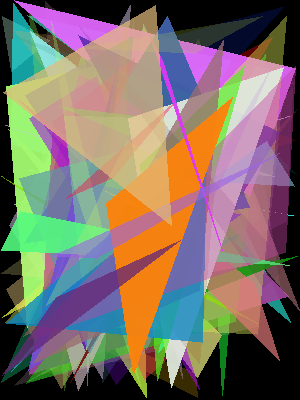

In [35]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [36]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [37]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

88.28124237060547

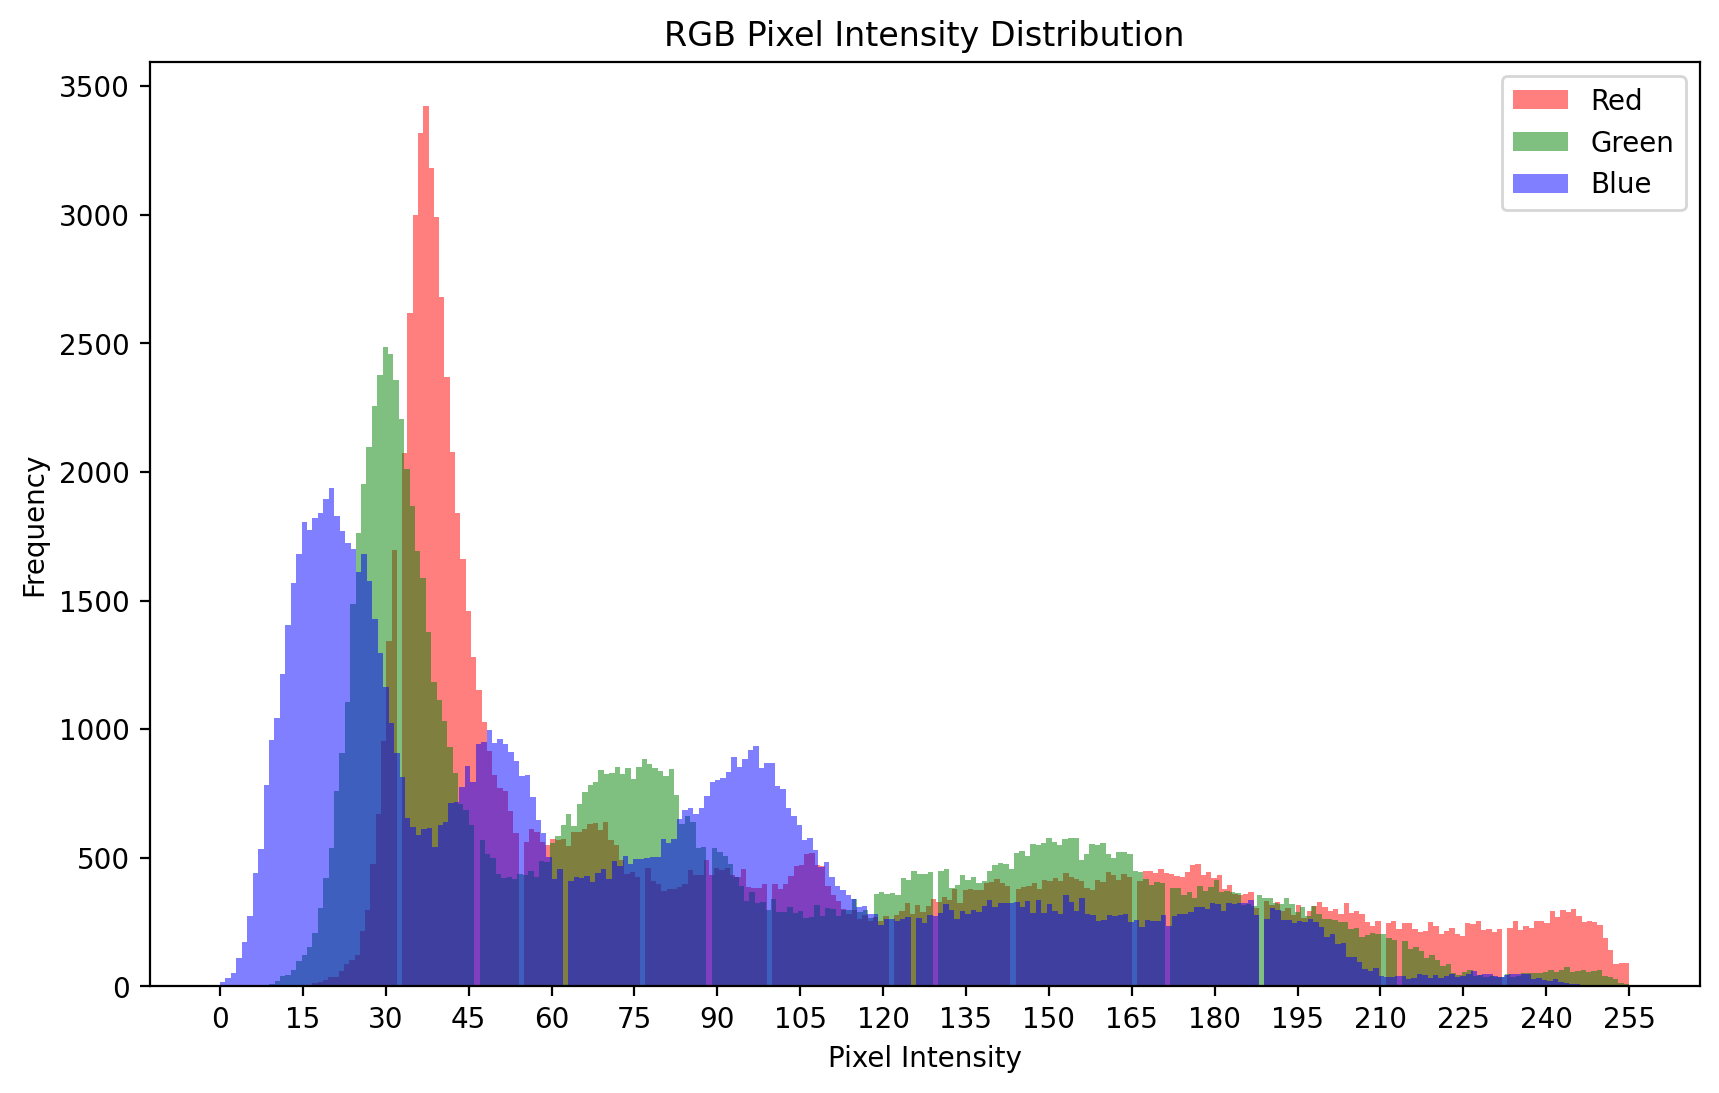

In [38]:
# Separate channels
r = target_array[:, :, 0].flatten()
g = target_array[:, :, 1].flatten()
b = target_array[:, :, 2].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color="red", alpha=0.5, label="Red")
plt.hist(g, bins=256, color="green", alpha=0.5, label="Green")
plt.hist(b, bins=256, color="blue", alpha=0.5, label="Blue")

plt.xticks(np.arange(0, 256, 15))  # ticks every 25
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Pixel Intensity Distribution")
plt.legend()
plt.show()

In [ ]:
ga = GeneticAlgorithm(
    target=target_array,
    triangle_alpha_range=(0, 140),
    fitness_function=fitness.compute_rmse,
    population_size=200,
    generations=800,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.9,
    mutation_function=mutate.volatile_triangle_mutation,
    mutation_rate=0.1,
    elitism=2,
    selection_type="tournament",
    logs=True,
    evaluation_backend="process",
    n_jobs=4,
    chunksize=5,
)

best_fitness, history = ga.run()
best_individual = ga.best_individual

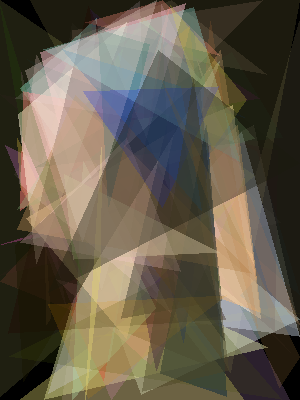

In [40]:
rendering.render_individual(individual=ga.best_individual)